In [1]:
from calculations.Composition.Composition import Composition
from calculations.Utils.Conditions import Conditions
from calculations.CompositionalModel.CompositionalModel import CompositionalModel
from calculations.EOS.PenelouxVolumeCorrection import PenelouxVolumeCorrection
from calculations.Utils.ResultsViewer import FlashResultsViewer, DLEResultsViewer, SeparatorTestResultsViewer, StandardSeparationResultsViewer
from calculations.Utils.CompositionLoader import CompositionExcelLoader

# KRSNLN

In [ ]:
excel_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\krsnln.xlsx')
krsnln_dict = excel_loader.load(header=True, sheet='to_model')

In [ ]:
krsnln_base_composition = Composition(zi = krsnln_dict)

In [ ]:
krsnln_model = CompositionalModel(krsnln_base_composition, eos= 'PREOS')

In [ ]:
conds = Conditions(14,60)
krsnln_model.flash(conditions=conds)

In [ ]:
krsnln_model.show_flashes

In [ ]:
krsnln_model.experiments.SEPARATORTEST.calculate_3stages([0.7, 0.5, 0.1], [20, 20, 20])

In [12]:
from calculations.PhaseDiagram.PhaseDiagram_v4 import PhaseDiagram

In [ ]:
phase_env = PhaseDiagram(zi = krsnln_base_composition, p_max=30, t_max=660, t_min=0, t_step=10)

In [ ]:
phase_env.calc_phase_diagram('PREOS')

In [ ]:
krsnln_model.plot_phase_diagram(p_max=26, t_max=660)

# PRRZLM №200839

In [2]:
excel_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\prrzlm.xlsx')
przlm_dict = excel_loader.load(header=True, sheet='to_model')

### Фактические данные

In [ ]:
p_sat = 120.47


## Создаем базовую модель и сравниваемся с PVTSIM

In [3]:
przlm_comp = Composition(przlm_dict)

In [4]:
przlm_comp.COMPOSITION_PROPERTIES

,molar_mass,gamma,Tb,critical_pressure,critical_temperature,acentric_factor,shift_parameter,critical_volume,bip,c5_plus_flag
N2,28.013,0.4700,77.39,3.394000,126.190000,0.040000,-0.192700,0.090100,"{'CO2': 0, 'N2': 0, 'C1': 0.003, 'C2': 0.011, ...",0
CO2,44.010,0.5000,194.67,7.387000,304.690000,0.225000,-0.081700,1.505735,"{'CO2': 0, 'N2': 0, 'C1': 0.004, 'C2': 0.009, ...",0
C1,16.043,0.3300,111.67,4.604000,190.600000,0.013000,-0.159500,1.585828,"{'CO2': 0.004, 'N2': 0.003, 'C1': 0, 'C2': 0.0...",0
C2,30.070,0.4500,184.56,4.884000,305.420000,0.099000,-0.113400,2.370730,"{'CO2': 0.009, 'N2': 0.011, 'C1': 0.024, 'C2':...",0
C3,44.097,0.5077,231.11,4.246000,369.790000,0.152000,-0.086300,3.251740,"{'CO2': 0, 'N2': 0, 'C1': 0.004, 'C2': 0.009, ...",0
iC4,58.124,0.5613,261.44,3.648000,408.090000,0.185000,-0.084400,4.212855,"{'CO2': 0.008, 'N2': 0.01, 'C1': 0.023, 'C2': ...",0
nC4,58.124,0.5844,272.67,3.797000,425.190000,0.201000,-0.094000,4.084708,"{'CO2': 0.023, 'N2': 0.026, 'C1': 0.045, 'C2':...",0
iC5,72.151,0.6274,301.00,3.389000,460.390000,0.227000,-0.060800,4.901640,"{'CO2': 0.04, 'N2': 0.044, 'C1': 0.067, 'C2': ...",0
nC5,72.151,0.6301,309.22,3.370000,469.590000,0.251000,-0.039000,4.869612,"{'CO2': 0, 'N2': 0, 'C1': 0, 'C2': 0, 'C3': 0,...",0
C6,86.178,0.6900,337.05,3.104000,507.500000,0.252000,-0.008000,5.926800,"{'CO2': 0.05, 'N2': 0.054, 'C1': 0.042, 'C2': ...",1


In [5]:
przlm_model = CompositionalModel(przlm_comp)

In [6]:
conds = Conditions(5,50)

In [7]:
przlm_model.flash(conds)

In [8]:
przlm_model.saturation_pressure(60)

8.80625
8.4953125
8.650781250000001
8.553613281250001
8.536001586914061
SATURATION PRESSURE CALCULATION
=====
CALCULATED SATURATION PRESSURE: 85.36001586914061 bar
TEMPERATURE: 60 C


### Проверяем сепаратор тест

In [ ]:
przlm_model.experiments.SEPARATORTEST.calculate_3stages([0.7, 0.5, 0.1], [20, 20, 20])

## Начинаем играть корреляциями

In [9]:
prr_base_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'rizari_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})


In [ ]:
prr_pedersen_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'pedersen',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

,molar_mass,gamma,Tb,critical_pressure,critical_temperature,acentric_factor,shift_parameter,critical_volume,c5_plus_flag
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,235.324025,0.777948,513.599500,2.317859,646.040657,0.707354,0.108961,15.502312,0.775000
std,151.968692,0.157837,200.195077,1.312239,201.921390,0.429286,0.145697,10.282038,0.422902
min,16.043000,0.330000,77.390000,1.311351,126.190000,0.013000,-0.192700,0.090100,0.000000
25%,93.544500,0.717750,358.050000,1.407845,527.029460,0.293227,-0.020308,6.078818,1.000000
50%,229.500000,0.847000,564.650000,1.675149,697.472980,0.724813,0.150584,14.792799,1.000000
75%,362.750000,0.893000,683.900000,3.077022,805.346890,1.075208,0.236398,24.015258,1.000000
max,500.000000,0.922000,766.150000,7.387000,898.796296,1.403862,0.291305,33.864255,1.000000


### Какие то расчеты, можно и убрать

In [ ]:
model_base = CompositionalModel(prr_base_comp)
model_kesler = CompositionalModel(prr_kesler_comp)

In [ ]:
model_kesler.experiments.SEPARATORTEST_MOD.calculate(150, 60, [0.76,0.3,0.101], [55, 58.3, 20])

In [ ]:
model_base.saturation_pressure(58)

In [ ]:
dleresview = DLEResultsViewer()
dleresview.view(model_kesler.experiments.SEPARATORTEST_MOD.result)

### Расчет фазовой по корреляции Ризари-Дауберта

In [13]:
phase_env_prr_rizari_daubert = PhaseDiagram(prr_base_comp, p_max=35, t_max= 550, t_min=0, t_step=10)

In [14]:
phase_env_prr_rizari_daubert.calc_phase_diagram('PREOS')

Pb найдено: 5.87734375
Pb найдено: 6.412597656250001
Pb найдено: 6.930859375
Pb найдено: 7.432128906250001
Pb найдено: 7.907910156250002
Pb найдено: 8.358203125000003
Pb найдено: 8.783007812500001
Pb найдено: 9.173828125
Pb найдено: 9.547656250000001
Pb найдено: 9.887500000000001
Pb найдено: 10.210351562500001
Pb найдено: 10.499218750000002
Pb найдено: 10.754101562500002
Pb найдено: 10.991992187500001
Pb найдено: 11.212890625
Pb найдено: 11.3998046875
Pb найдено: 11.552734375
Pb найдено: 11.7056640625
Pb найдено: 11.824609375000001
Pb найдено: 11.9265625
Pb найдено: 11.99453125
Pb найдено: 12.0625
Pb найдено: 12.096484375
Pb найдено: 12.1134765625
Pb найдено: 12.13046875
Pb найдено: 12.1134765625
Pb найдено: 12.0794921875
Pb найдено: 12.028515625
Pb найдено: 11.9775390625
Pdew найдено: 0.0017648027278482914
Pb найдено: 11.892578125
Pdew найдено: 0.002795715816318989
Pb найдено: 11.8076171875
Pdew найдено: 0.004335339181125164
Pb найдено: 11.7056640625
Pdew найдено: 0.006580819096416234

In [15]:
phase_env_data_1 = phase_env_prr_rizari_daubert.get_phase_diagram_data()

### Расчет фазовой по корреляции Pedersen

In [16]:
phase_env_prr_pedersen = PhaseDiagram(prr_pedersen_comp, p_max=35, t_max= 550, t_min=0, t_step=10)
phase_env_prr_pedersen.calc_phase_diagram('PREOS')

Pb найдено: 6.845898437499999
Pb найдено: 7.4576171875
Pb найдено: 8.0353515625
Pb найдено: 8.596093750000001
Pb найдено: 9.13134765625
Pb найдено: 9.632617187500001
Pb найдено: 10.1083984375
Pb найдено: 10.541699218750004
Pb найдено: 10.941015625000002
Pb найдено: 11.314843750000001
Pb найдено: 11.654687500000001
Pb найдено: 11.9775390625
Pb найдено: 12.2494140625
Pb найдено: 12.504296874999998
Pb найдено: 12.7251953125
Pb найдено: 12.929101562500001
Pb найдено: 13.0990234375
Pb найдено: 13.251953125
Pb найдено: 13.35390625
Pb найдено: 13.455859375
Pb найдено: 13.523828125000001
Pb найдено: 13.591796875
Pb найдено: 13.625781250000001
Pb найдено: 13.625781250000001
Pb найдено: 13.625781250000001
Pb найдено: 13.591796875
Pb найдено: 13.5578125
Pb найдено: 13.48984375
Pb найдено: 13.421875
Pdew найдено: 0.002355217933654785
Pb найдено: 13.319921874999999
Pdew найдено: 0.003734643012285232
Pb найдено: 13.200976562500001
Pdew найдено: 0.005784844141453504
Pb найдено: 13.08203125
Pdew найде

In [17]:
phase_env_data_2 = phase_env_prr_pedersen.get_phase_diagram_data()

### Расчет по корреляции Kesler-Lee

In [18]:
prr_kesler_lee_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'kesler_lee',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [19]:
phase_env_prr_kesler_lee = PhaseDiagram(prr_kesler_lee_comp, p_max=35, t_max= 550, t_min=0, t_step=10)
phase_env_prr_kesler_lee.calc_phase_diagram('PREOS')

Pb найдено: 5.7159179687499995
Pb найдено: 6.234179687499999
Pb найдено: 6.743945312499999
Pb найдено: 7.22822265625
Pb найдено: 7.695507812500001
Pb найдено: 8.1373046875
Pb найдено: 8.5451171875
Pb найдено: 8.935937500000001
Pb найдено: 9.309765625
Pb найдено: 9.64111328125
Pb найдено: 9.955468750000001
Pb найдено: 10.227343750000001
Pb найдено: 10.490722656250004
Pb найдено: 10.720117187500001
Pb найдено: 10.9240234375
Pb найдено: 11.110937500000002
Pb найдено: 11.280859375000002
Pb найдено: 11.416796875
Pb найдено: 11.5357421875
Pb найдено: 11.637695312500002
Pb найдено: 11.7056640625
Pb найдено: 11.7736328125
Pb найдено: 11.8076171875
Pb найдено: 11.824609375000001
Pb найдено: 11.841601562500001
Pb найдено: 11.824609375000001
Pb найдено: 11.8076171875
Pb найдено: 11.756640625
Pb найдено: 11.7056640625
Pb найдено: 11.637695312500002
Pb найдено: 11.552734375
Pdew найдено: 0.003927755169570446
Pb найдено: 11.45078125
Pdew найдено: 0.005962492525577546
Pb найдено: 11.348828125
Pdew на

In [ ]:
phase_env_data_3 = phase_env_prr_kesler_lee.get_phase_diagram_data()

###  Расчет по корреляции Sim-Daubert

In [23]:
prr_sim_daubert_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'sim_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [24]:
phase_env_prr_sim_daubert = PhaseDiagram(prr_sim_daubert_comp, p_max=35, t_max= 550, t_min=0, t_step=10)
phase_env_prr_sim_daubert.calc_phase_diagram('PREOS')

Pb найдено: 6.20869140625
Pb найдено: 6.7779296875
Pb найдено: 7.3216796875
Pb найдено: 7.839941406250001
Pb найдено: 8.341210937500001
Pb найдено: 8.808496093750001
Pb найдено: 9.25029296875
Pb найдено: 9.666601562500002
Pb найдено: 10.0404296875
Pb найдено: 10.397265625000003
Pb найдено: 10.720117187500001
Pb найдено: 11.025976562500002
Pb найдено: 11.297851562500002
Pb найдено: 11.5357421875
Pb найдено: 11.756640625
Pb найдено: 11.943554687499999
Pb найдено: 12.1134765625
Pb найдено: 12.2494140625
Pb найдено: 12.368359375
Pb найдено: 12.470312499999999
Pb найдено: 12.555273437499999
Pb найдено: 12.60625
Pb найдено: 12.640234374999999
Pb найдено: 12.67421875
Pb найдено: 12.67421875
Pdew найдено: 0.000229654461145401
Pb найдено: 12.6572265625
Pdew найдено: 0.00040437420830130577
Pb найдено: 12.623242187499999
Pb найдено: 12.572265625
Pb найдено: 12.504296874999998
Pb найдено: 12.436328125
Pb найдено: 12.334375
Pdew найдено: 0.004593442380428314
Pb найдено: 12.232421875
Pdew найдено: 0

In [25]:
phase_env_data_4 = phase_env_prr_sim_daubert.get_phase_diagram_data()

### Pc Br **не работает!**

## Построение общей фазовой и сравнение результатов

Text(0, 0.5, 'Pressure, MPa')

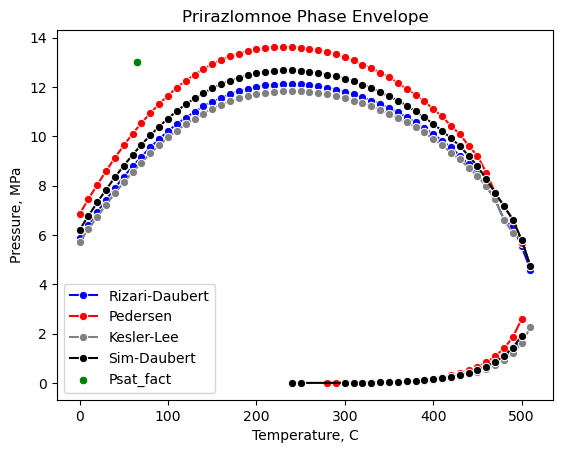

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.lineplot(marker='o',data = phase_env_data_1, x= phase_env_data_1['Temp'], y= phase_env_data_1['Up'], color = 'blue', label = 'Rizari-Daubert')
sns.lineplot(marker='o',data = phase_env_data_1, x= phase_env_data_1['Temp'], y= phase_env_data_1['Low'], color = 'blue')
sns.lineplot(marker='o',data = phase_env_data_2, x= phase_env_data_2['Temp'], y= phase_env_data_2['Up'], color = 'red', label = 'Pedersen')
sns.lineplot(marker='o',data = phase_env_data_2, x= phase_env_data_2['Temp'], y= phase_env_data_2['Low'], color = 'red')
sns.lineplot(marker='o',data = phase_env_data_3, x= phase_env_data_3['Temp'], y= phase_env_data_3['Up'], color = 'gray', label = 'Kesler-Lee')
sns.lineplot(marker='o',data = phase_env_data_3, x= phase_env_data_3['Temp'], y= phase_env_data_3['Low'], color = 'gray')
sns.lineplot(marker='o',data = phase_env_data_4, x= phase_env_data_4['Temp'], y= phase_env_data_4['Up'], color = 'black', label = 'Sim-Daubert')
sns.lineplot(marker='o',data = phase_env_data_4, x= phase_env_data_4['Temp'], y= phase_env_data_4['Low'], color = 'black')
sns.scatterplot(x=[65], y = [13], color = 'green', label = 'Psat_fact')
plt.title('Prirazlomnoe Phase Envelope')
plt.xlabel('Temperature, C')
plt.ylabel('Pressure, MPa')
